## 1. Imports

In [1]:
import sys
import os
import re
import gc
import json
from pathlib import Path
 
sys.path.append(str(Path.cwd().parent / "src"))
 
import torch
from torch.utils.data import DataLoader

import numpy as np
import h5py
import matplotlib.pyplot as plt
 
from paths import CHECKPOINT_DIR  # TRAIN/VAL/TEST paths are now built per exp_key below
 
from amr_dataset import AMRDataset
from utils import (get_device, load_best_model, high_snr_confusion)
 
from viz import (plot_training_curves,
                 plot_accuracy_vs_snr_comparison,
                 accuracy_vs_snr_table,
                 collect_predictions,
                 plot_confusion_matrix,
                 plot_accuracy_vs_snr)
 
from train import train_model
from models import BaselineCNN
 
 
%matplotlib inline
 

## 2. Discover exp-k-i datasets and build split paths

In [2]:
DATA_DIR = Path.cwd().parent / "data"
 
EXP_DIR_PATTERN = re.compile(r'^exp-[A-C]-[1-3]$')
 
exp_folders = sorted(
    d.name for d in DATA_DIR.iterdir()
    if d.is_dir() and EXP_DIR_PATTERN.match(d.name)
)
 
print(f"Found {len(exp_folders)} exp-k-i folder(s):")
for d in exp_folders:
    print(f"  {d}")
 
 
def split_paths_3dom(exp_key):
    """Train/val/test paths for the 3-domain (Rma+Umi+Uma) split of exp_key."""
    base = DATA_DIR / exp_key / "splits" / "rma_umi_uma"
    return base / "train.h5", base / "val.h5", base / "test.h5"
 
 
DOMAIN_VARIANTS = [
    ("pooled",   None),
    ("rma_only", 0),
    ("umi_only", 1),
    ("uma_only", 2),
]

Found 6 exp-k-i folder(s):
  exp-A-1
  exp-A-2
  exp-A-3
  exp-B-1
  exp-B-2
  exp-B-3


## 3. Device Check and File Loading Checks

In [3]:
device = get_device()
print(f"Using device: {device}")
 
for exp_key in exp_folders:
    train_path, val_path, test_path = split_paths_3dom(exp_key)
    print(f"{exp_key}: train={train_path.exists()} val={val_path.exists()} test={test_path.exists()}")

Using device: cuda
exp-A-1: train=True val=True test=True
exp-A-2: train=True val=True test=True
exp-A-3: train=True val=True test=True
exp-B-1: train=True val=True test=True
exp-B-2: train=True val=True test=True
exp-B-3: train=True val=True test=True


## 4. Sanity check — load one batch from the first available dataset

In [4]:
_sanity_exp_key = exp_folders[0]
_train_path, _, _ = split_paths_3dom(_sanity_exp_key)
 
_sanity_ds = AMRDataset(_train_path, normalize="per_sample")
_sanity_loader = DataLoader(_sanity_ds, batch_size=256, shuffle=True)
 
iq, mod_label, snr, domain = next(iter(_sanity_loader))
 
print(f"Sanity check on {_sanity_exp_key}")
print("iq shape:", iq.shape)
print("mod_label shape:", mod_label.shape)
print("snr shape:", snr.shape)
print("domain shape:", domain.shape)
 
del _sanity_ds, _sanity_loader
gc.collect()

Sanity check on exp-A-1
iq shape: torch.Size([256, 2, 1024])
mod_label shape: torch.Size([256])
snr shape: torch.Size([256])
domain shape: torch.Size([256])


40

## 5. Train + evaluate all four variants, for every exp-k-i


########## exp-A-1 ##########
--- training exp-A-1_baseline_pooled (domain_filter=None) ---
Using device: cuda
[exp-A-1_baseline_pooled] epoch   1/20 train_loss=1.0792 train_acc=0.4787 val_loss=1.0865 val_acc=0.4670 (13.3s)
  -> saved new best checkpoint (val_acc=0.4670)
[exp-A-1_baseline_pooled] epoch   2/20 train_loss=0.9665 train_acc=0.5322 val_loss=0.9470 val_acc=0.5449 (11.7s)
  -> saved new best checkpoint (val_acc=0.5449)
[exp-A-1_baseline_pooled] epoch   3/20 train_loss=0.9483 train_acc=0.5408 val_loss=0.9495 val_acc=0.5353 (12.5s)
[exp-A-1_baseline_pooled] epoch   4/20 train_loss=0.9378 train_acc=0.5445 val_loss=0.9388 val_acc=0.5380 (11.8s)
[exp-A-1_baseline_pooled] epoch   5/20 train_loss=0.9277 train_acc=0.5484 val_loss=0.9137 val_acc=0.5557 (11.8s)
  -> saved new best checkpoint (val_acc=0.5557)
[exp-A-1_baseline_pooled] epoch   6/20 train_loss=0.9183 train_acc=0.5512 val_loss=1.0332 val_acc=0.5126 (12.7s)
[exp-A-1_baseline_pooled] epoch   7/20 train_loss=0.9065 train_acc

/home/courier/luebeck/lub-amr/src/viz.py:160: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(6, 5))


   SNR |    pooled |  rma_only |  umi_only |  uma_only
 -10.0 |     0.356 |     0.363 |     0.330 |     0.352
  -8.0 |     0.469 |     0.458 |     0.430 |     0.471
  -6.0 |     0.547 |     0.563 |     0.533 |     0.552
  -4.0 |     0.481 |     0.487 |     0.520 |     0.467
  -2.0 |     0.453 |     0.428 |     0.454 |     0.416
   0.0 |     0.512 |     0.449 |     0.458 |     0.473
   2.0 |     0.590 |     0.502 |     0.548 |     0.577
   4.0 |     0.599 |     0.597 |     0.604 |     0.599
   6.0 |     0.621 |     0.618 |     0.668 |     0.615
   8.0 |     0.786 |     0.682 |     0.735 |     0.669
  10.0 |     0.828 |     0.743 |     0.733 |     0.739
  12.0 |     0.833 |     0.781 |     0.739 |     0.754
  14.0 |     0.826 |     0.792 |     0.723 |     0.776
  16.0 |     0.840 |     0.780 |     0.712 |     0.781
  18.0 |     0.850 |     0.781 |     0.704 |     0.788
  20.0 |     0.849 |     0.780 |     0.707 |     0.789
=== exp-A-2 — POOLED high-SNR confusion ===
n=4606 samples at SNR

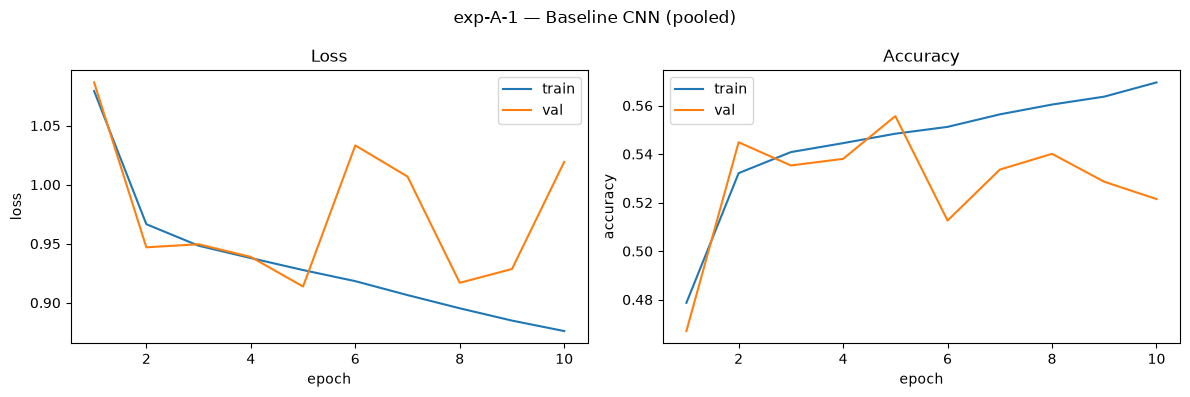

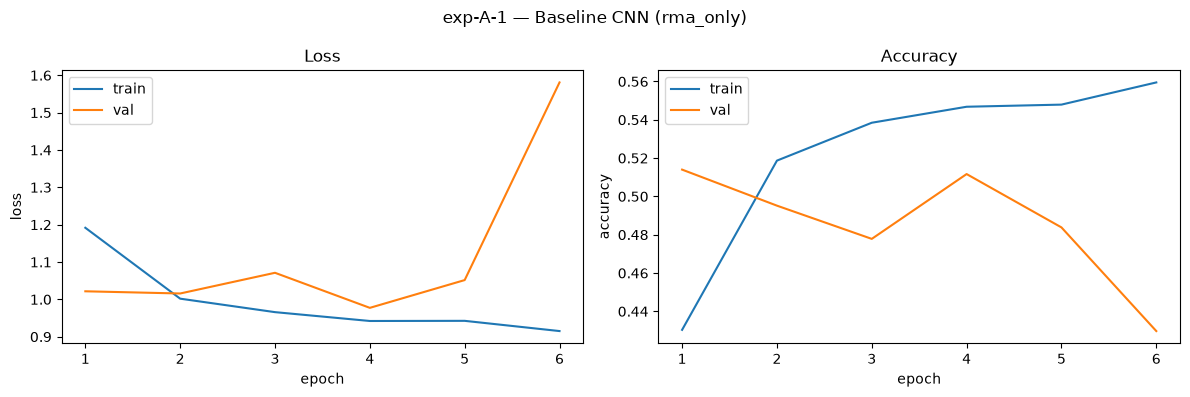

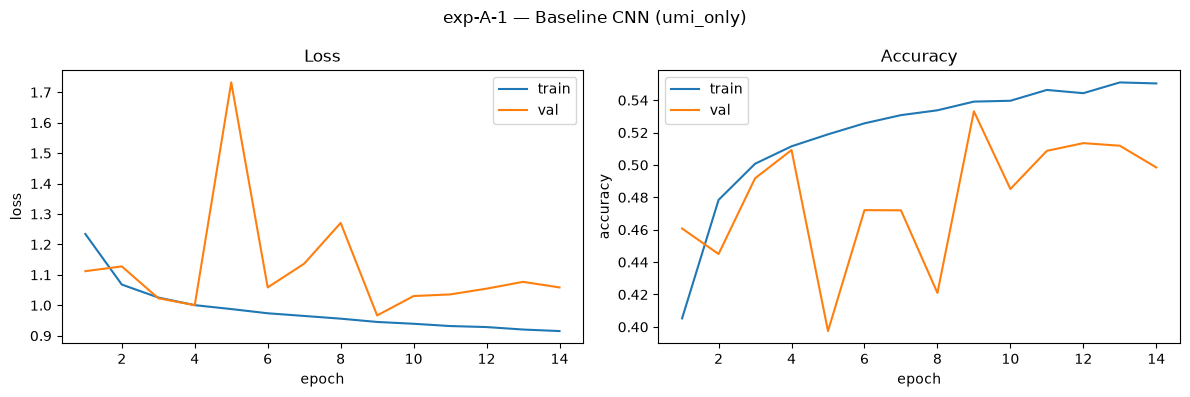

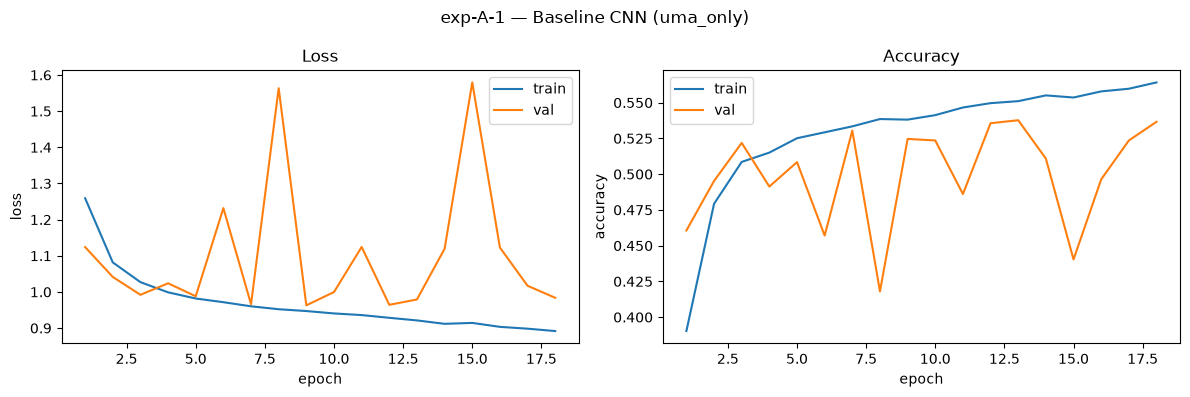

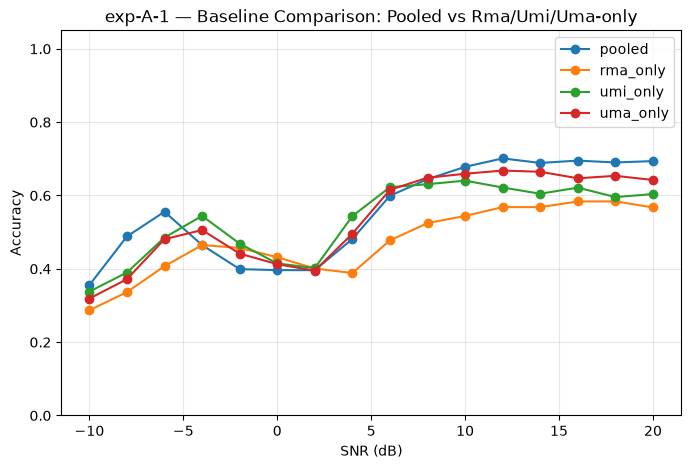

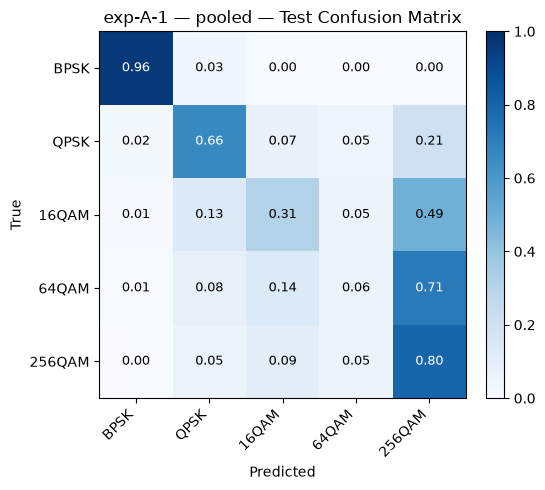

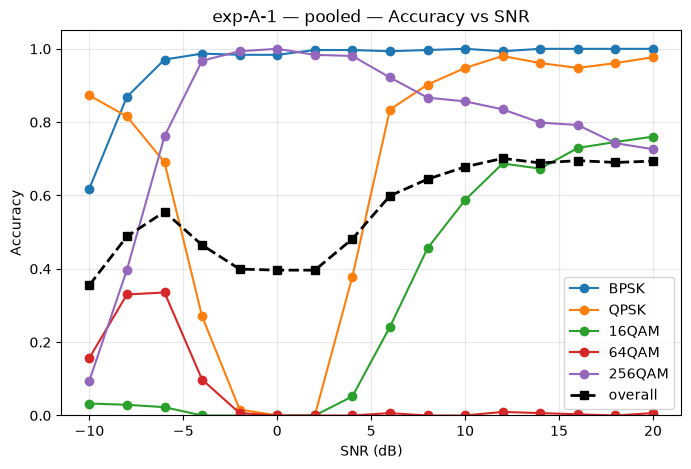

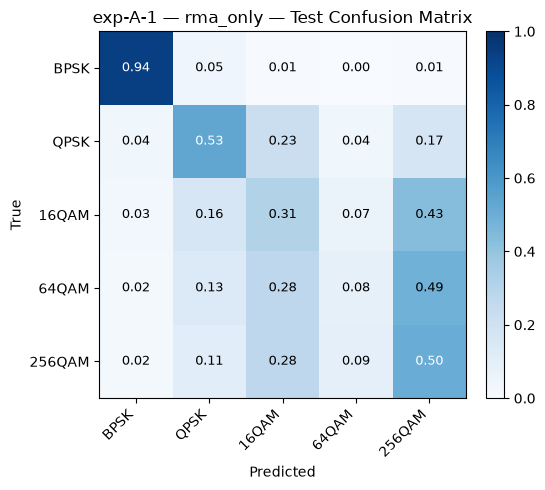

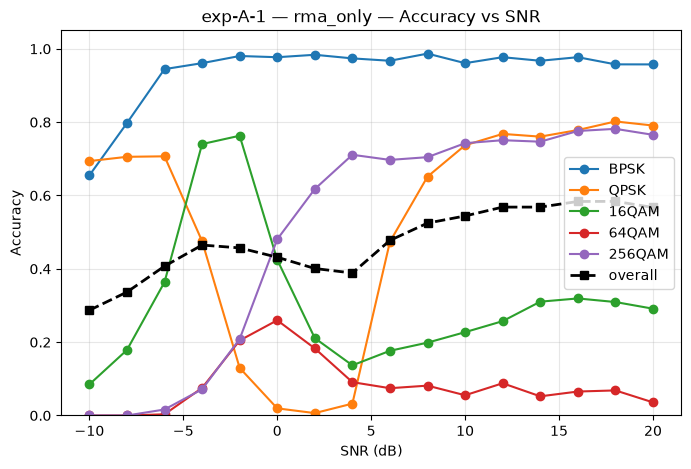

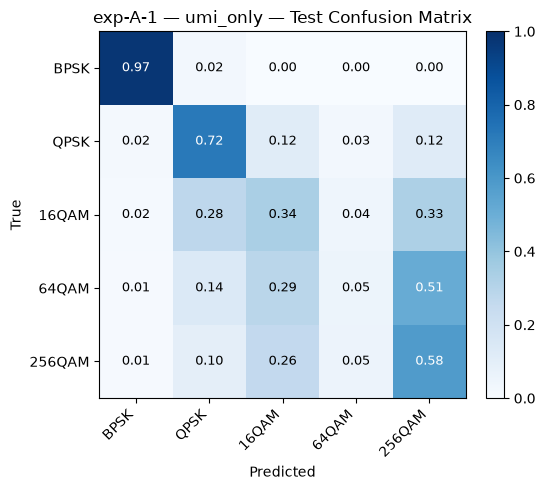

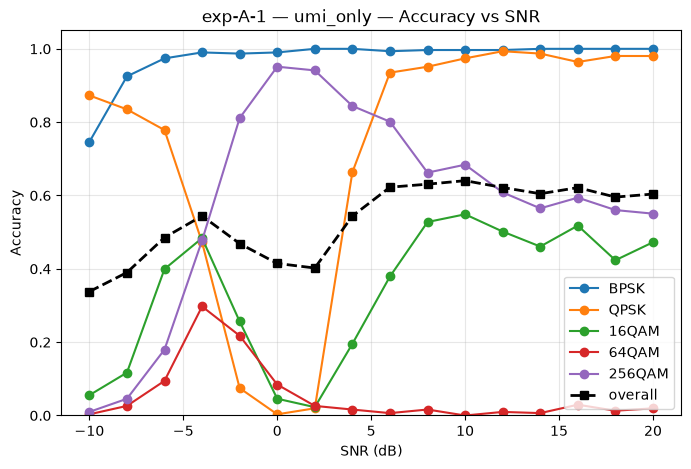

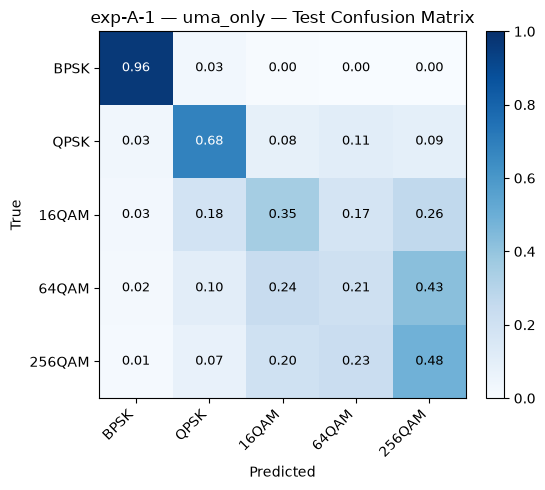

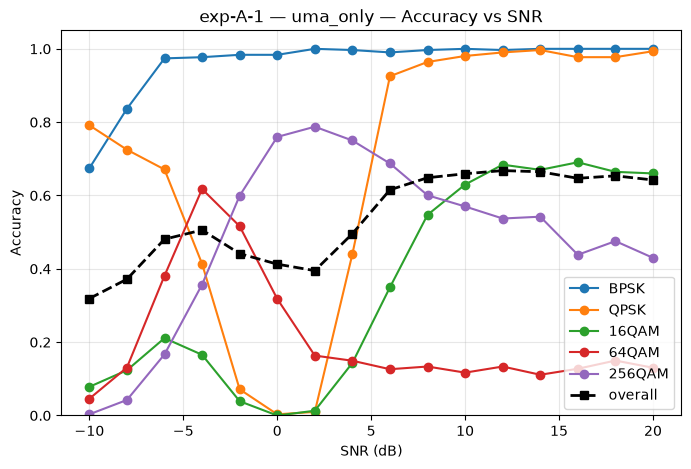

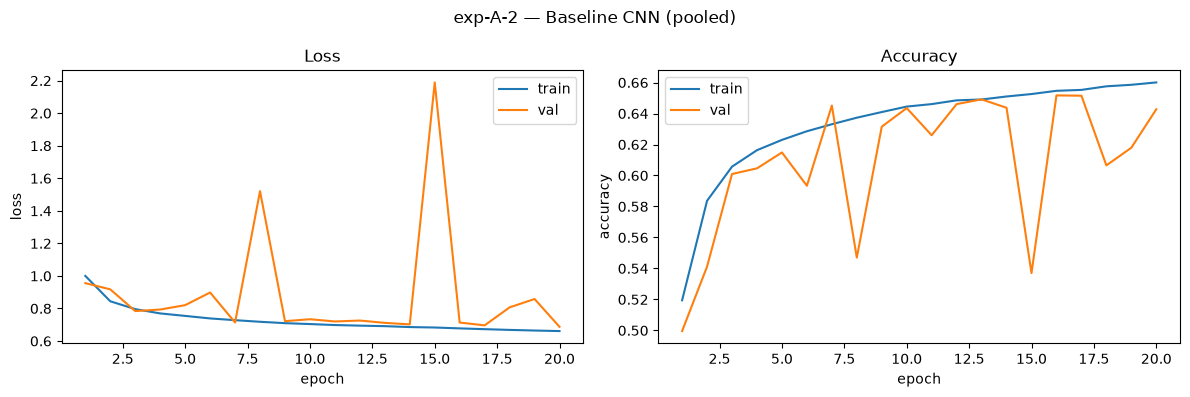

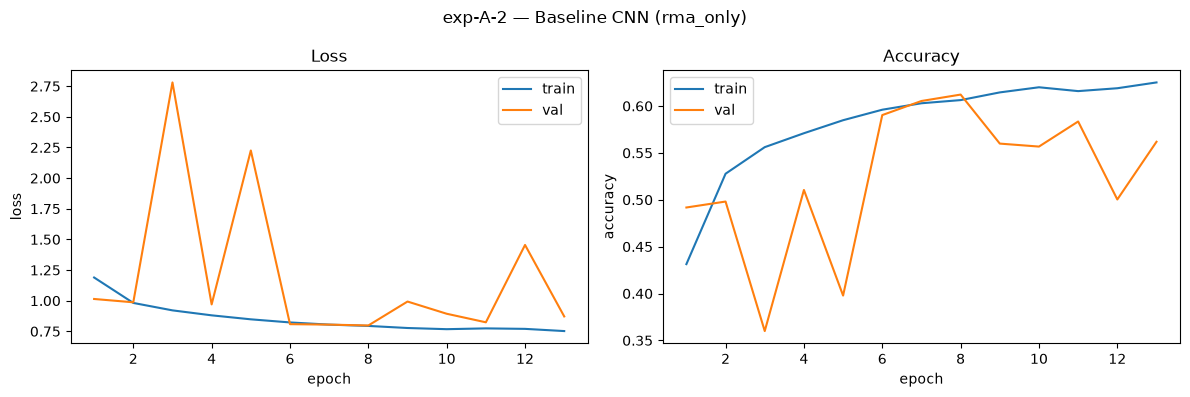

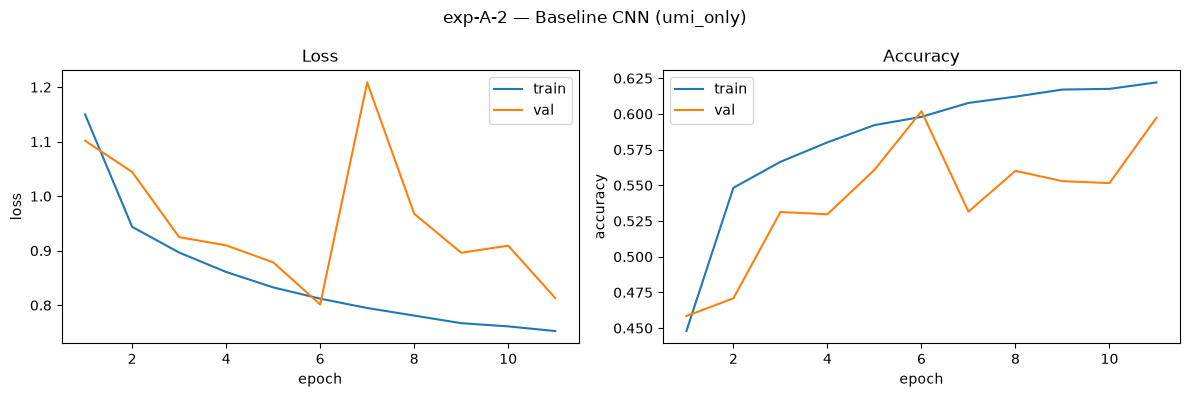

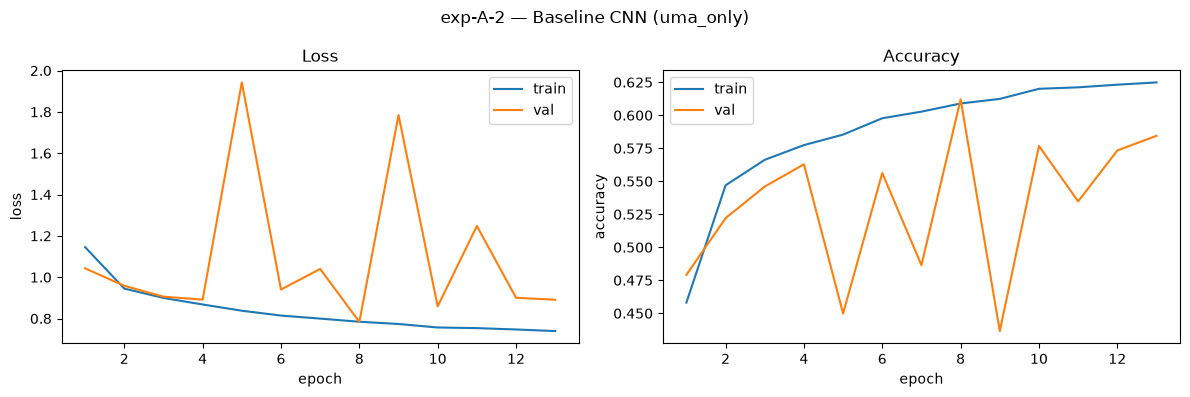

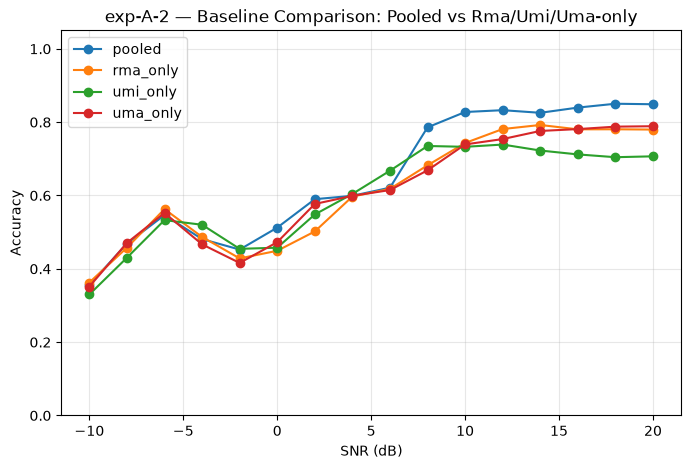

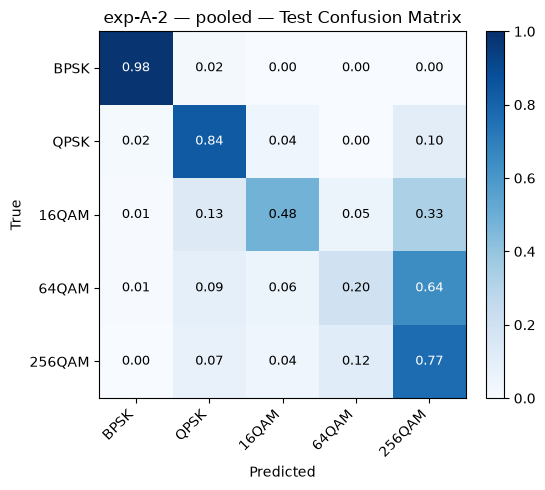

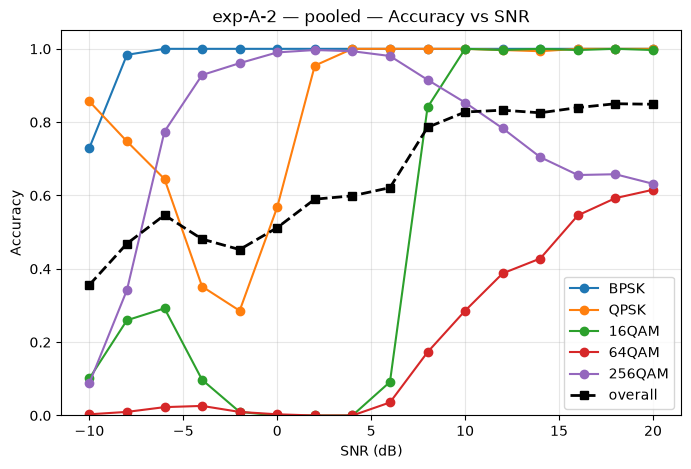

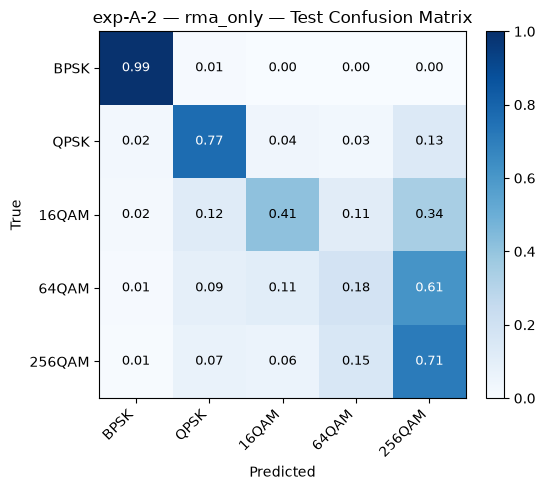

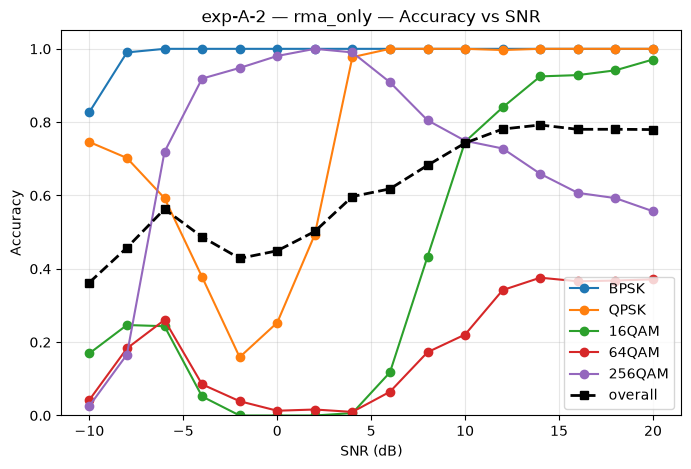

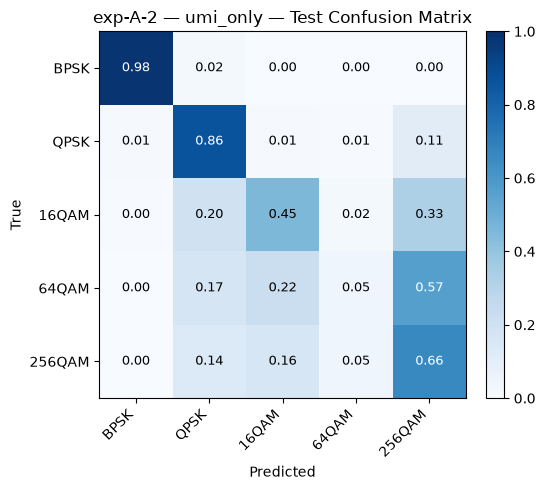

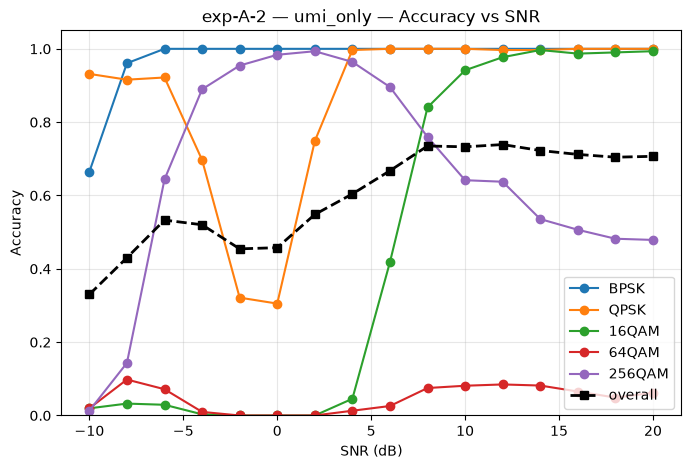

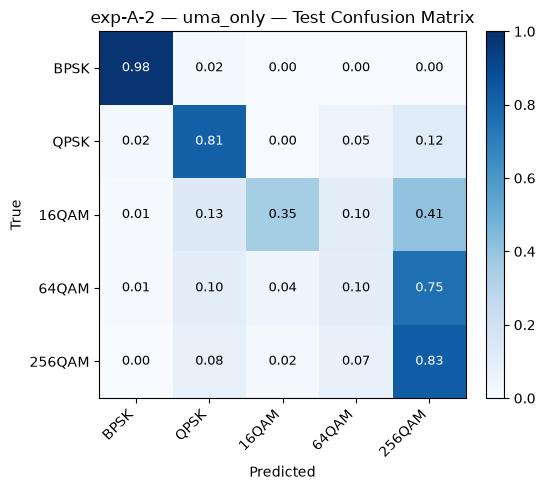

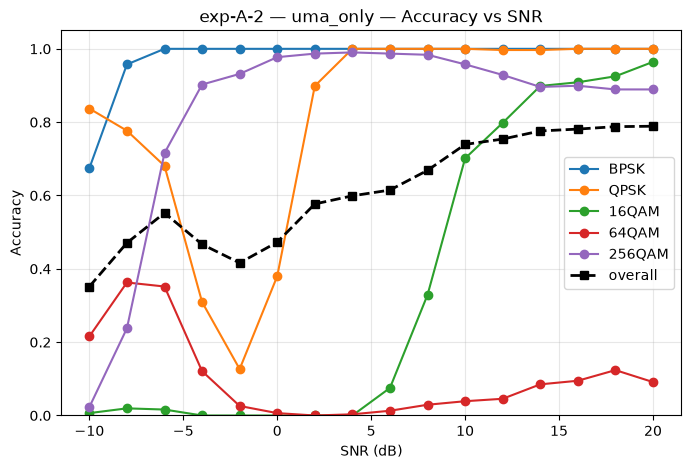

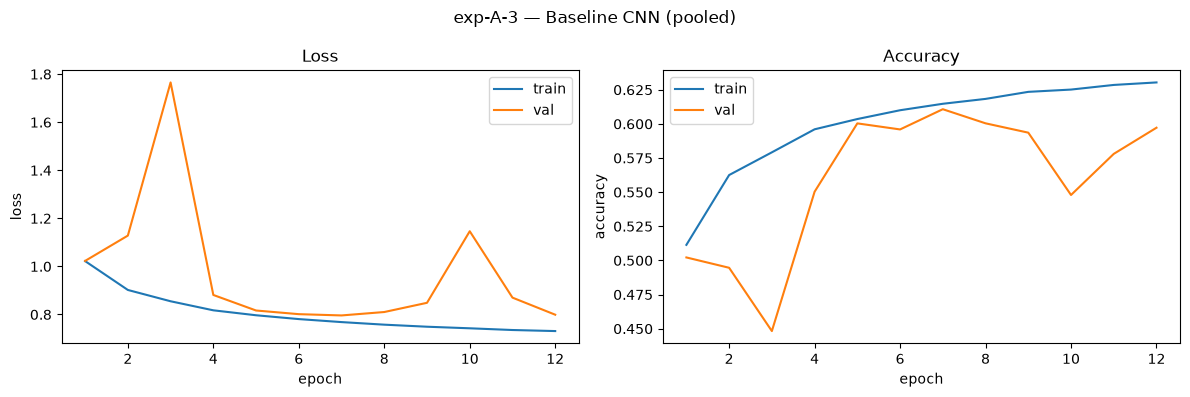

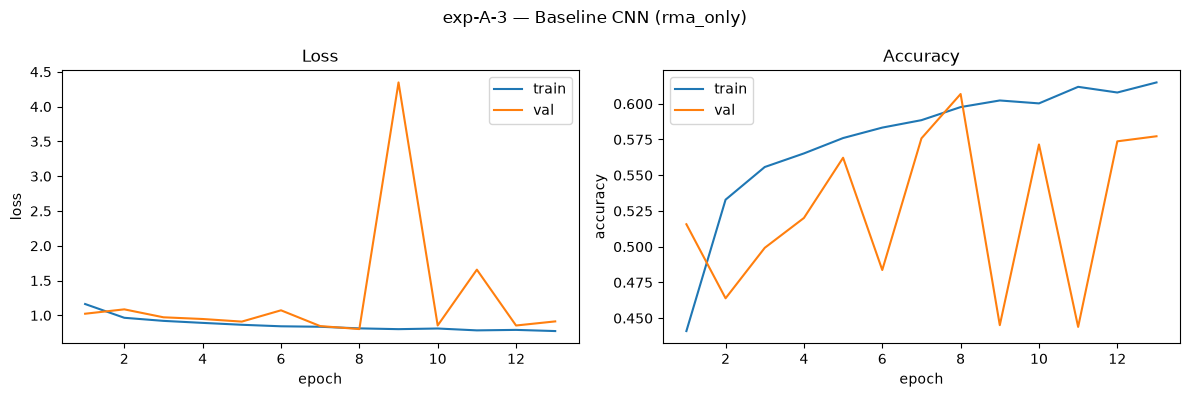

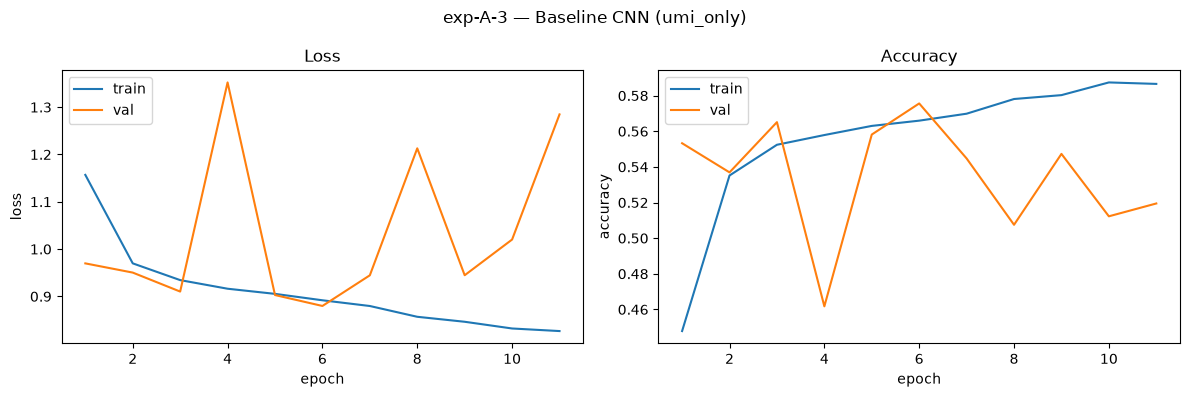

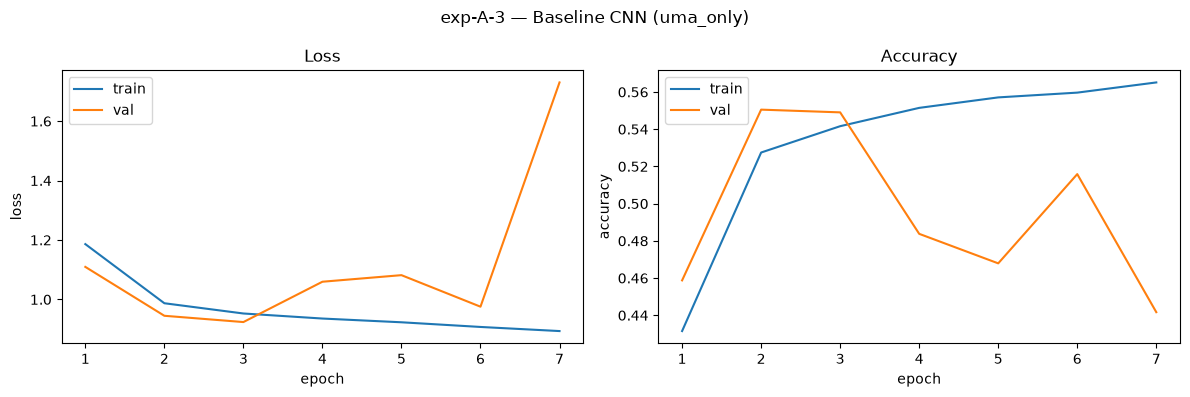

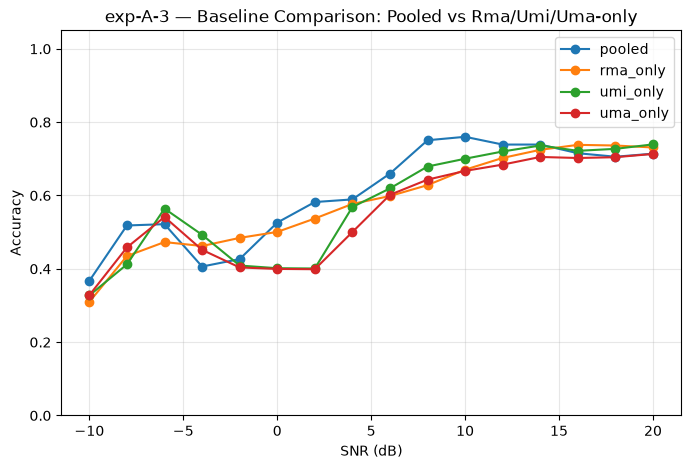

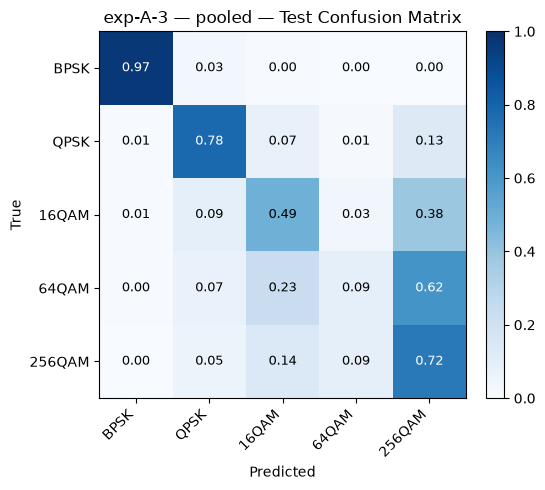

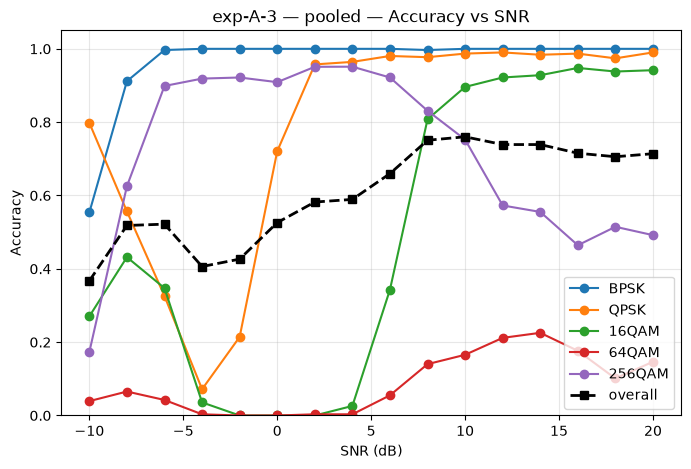

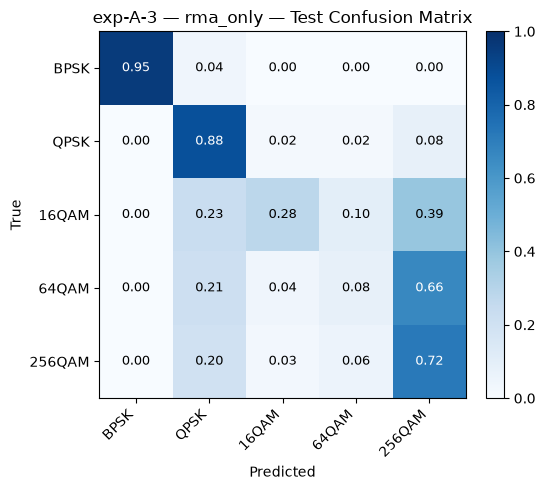

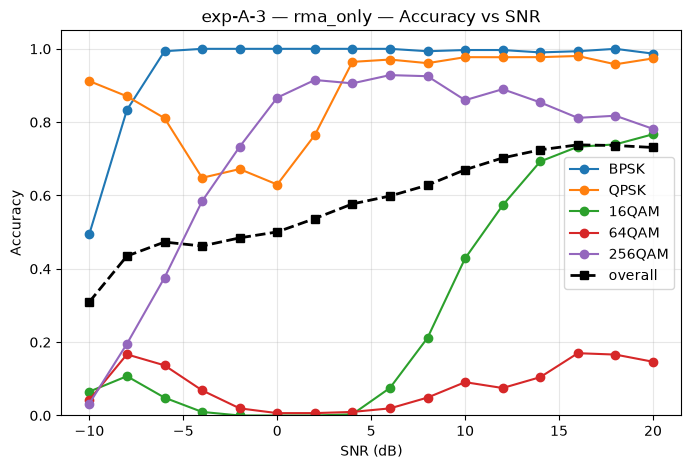

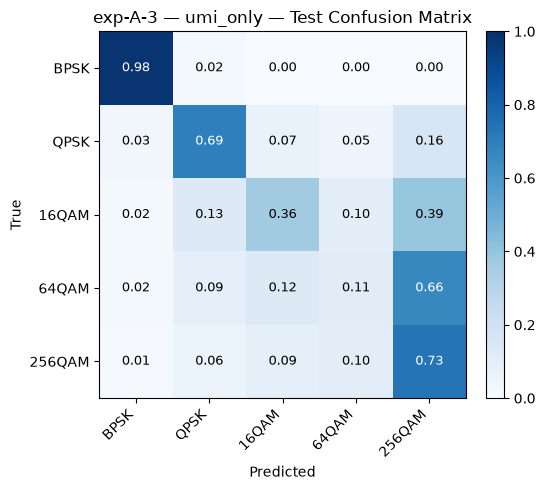

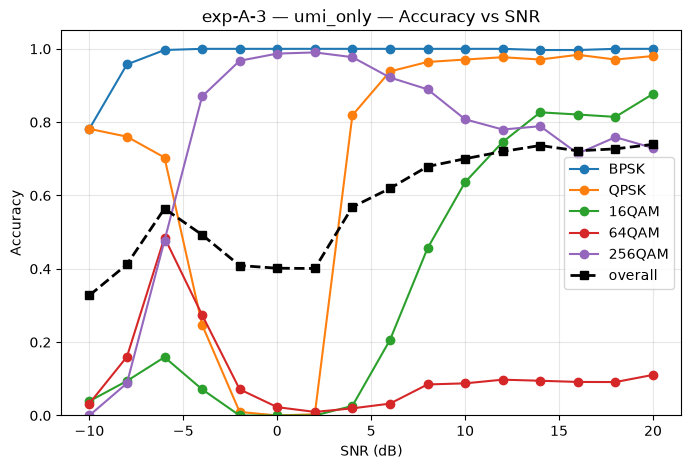

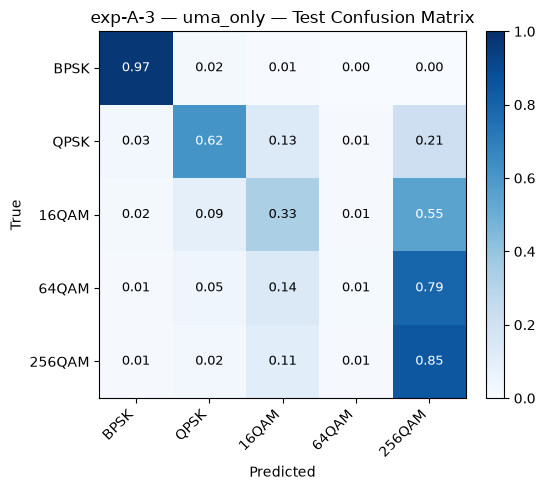

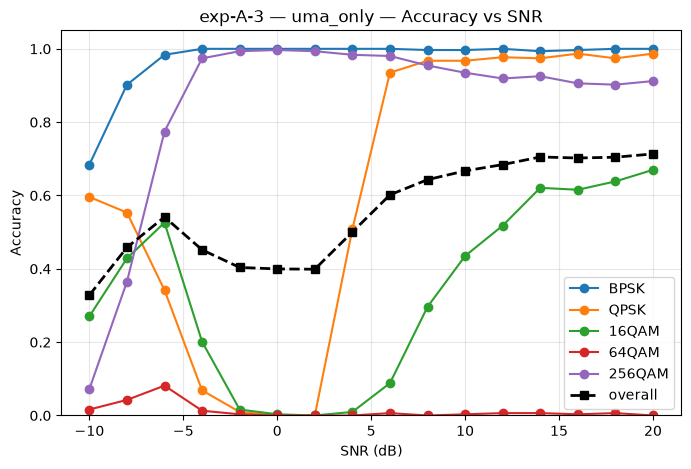

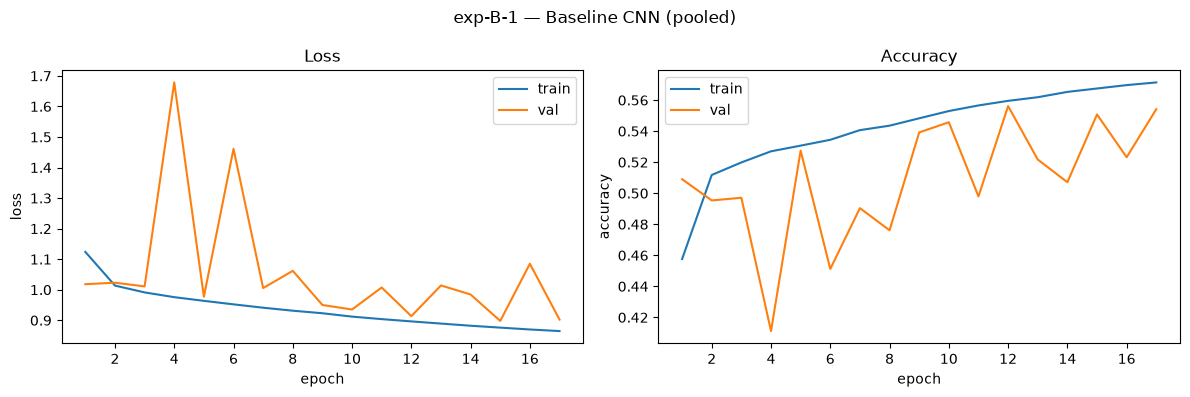

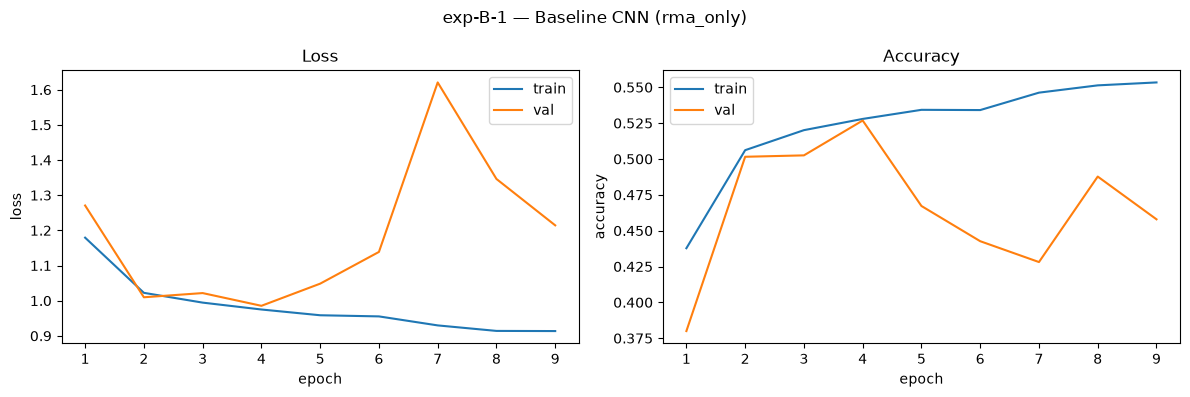

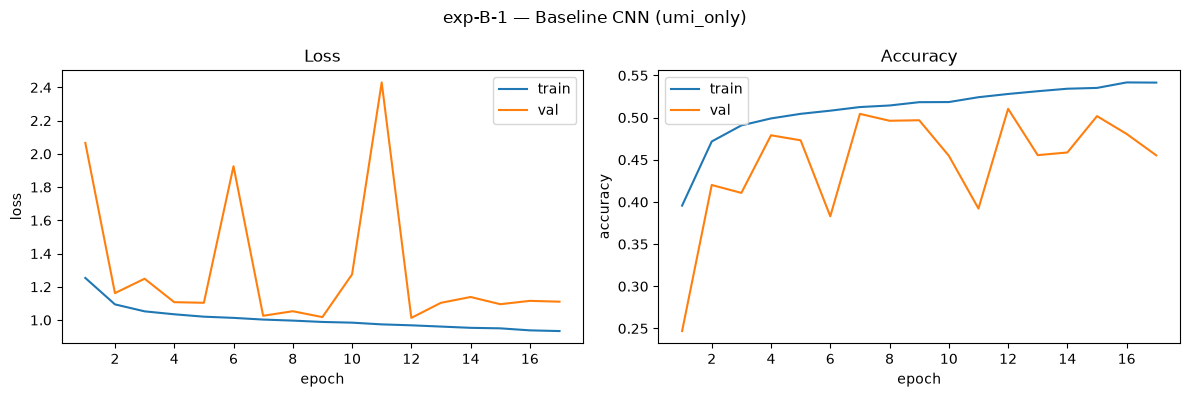

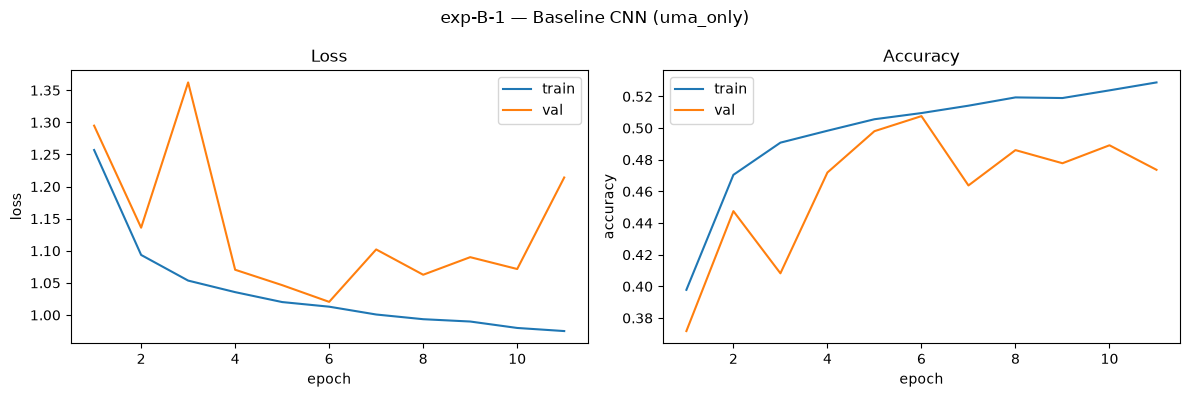

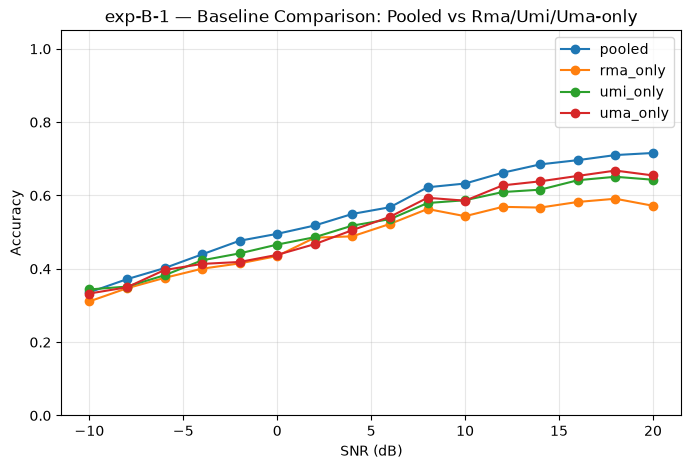

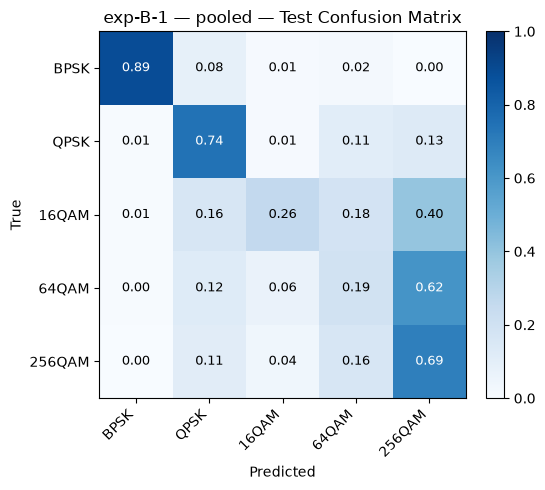

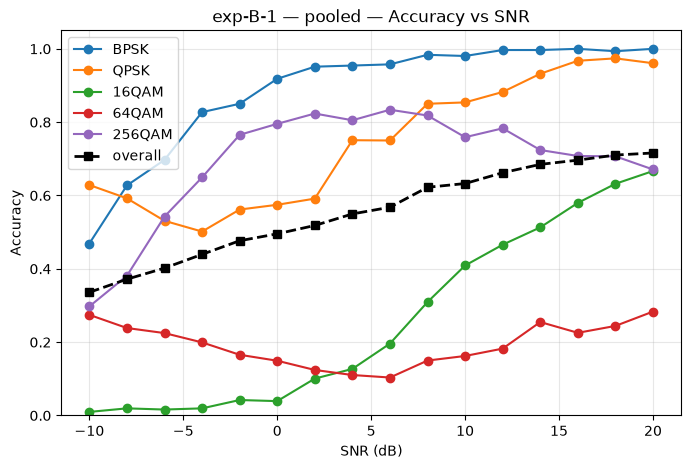

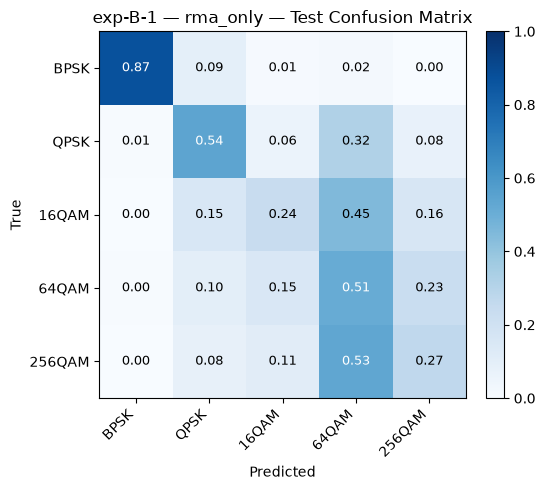

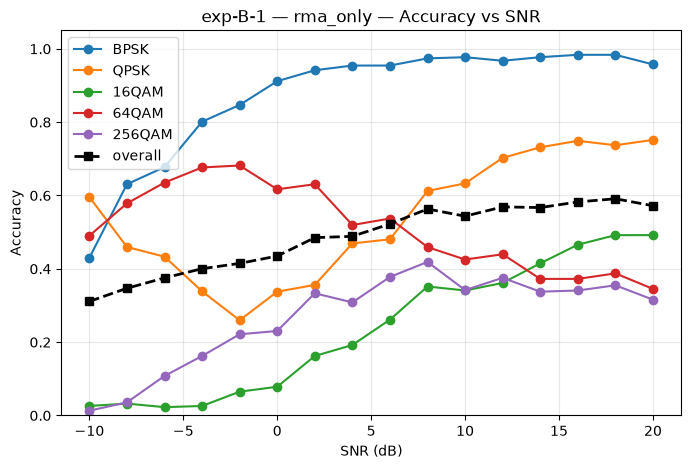

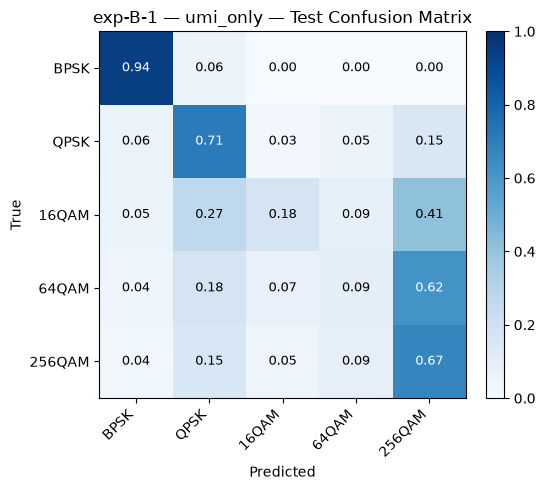

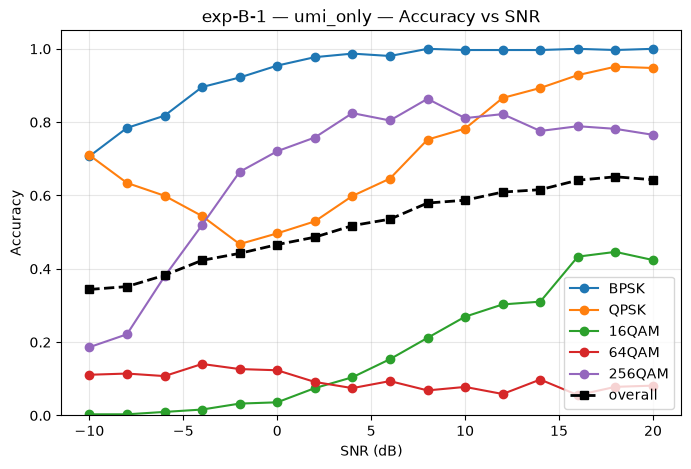

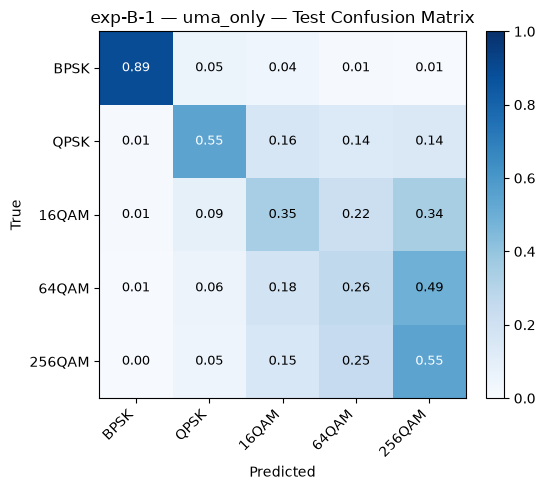

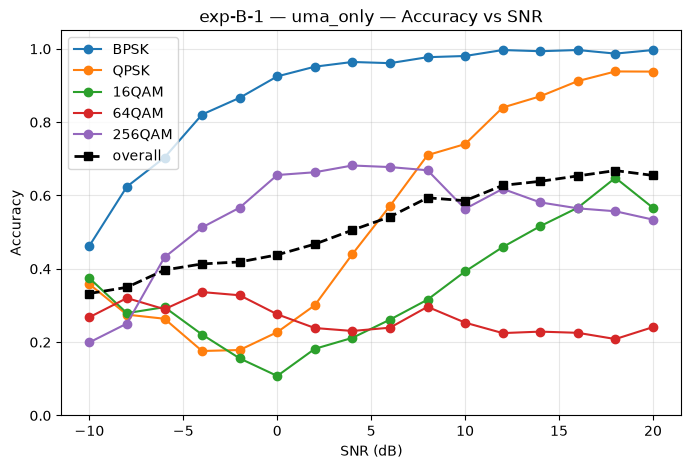

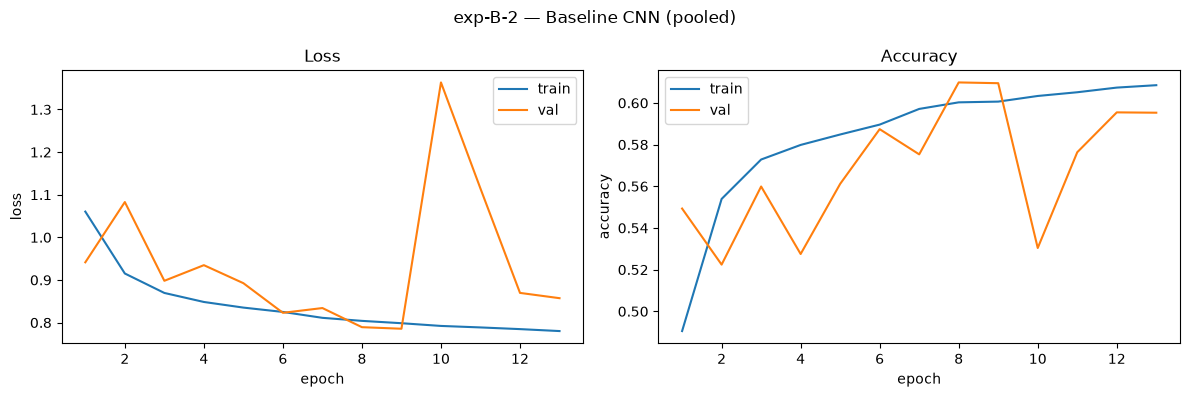

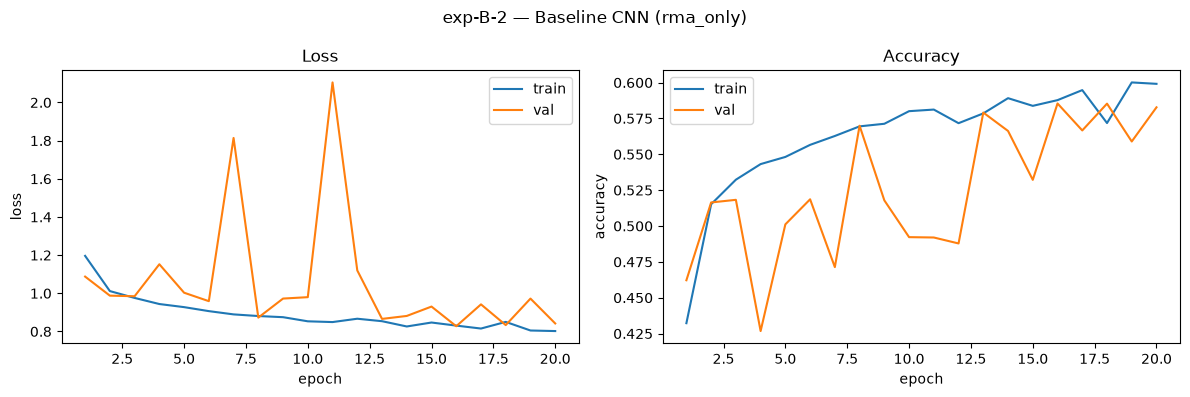

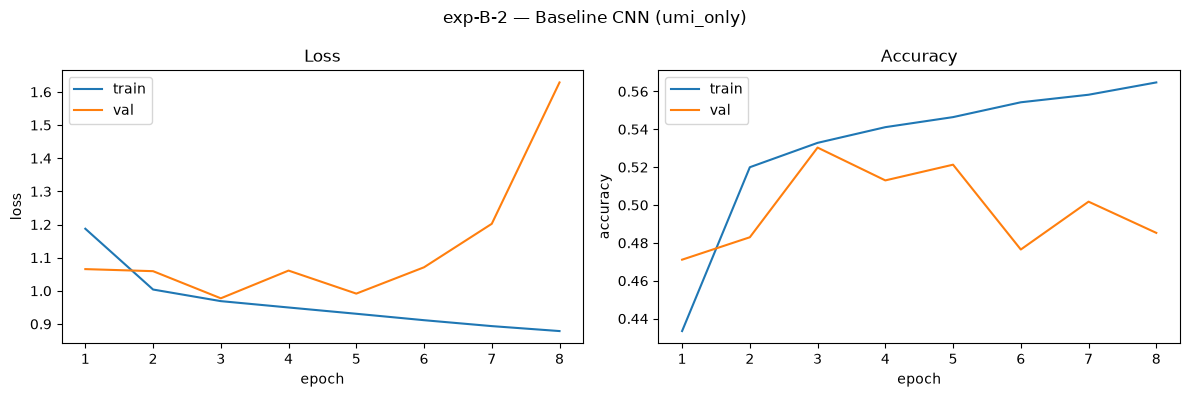

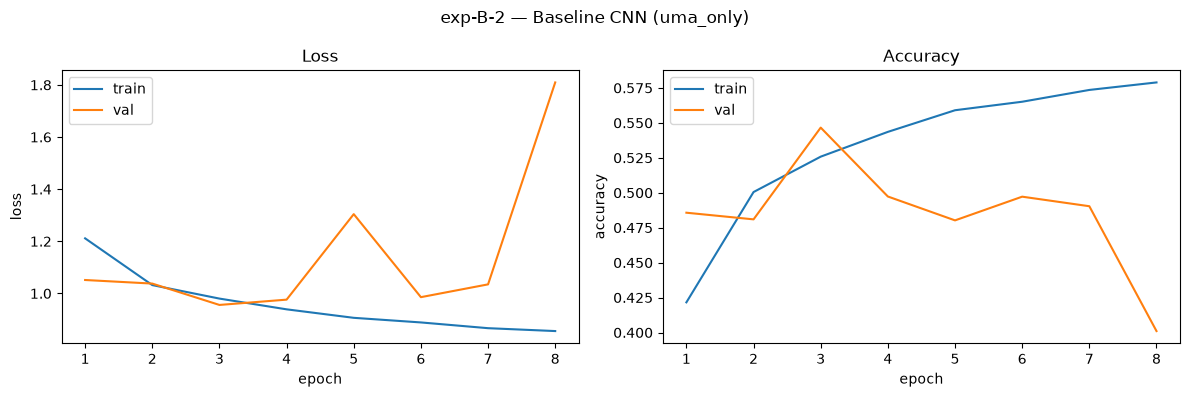

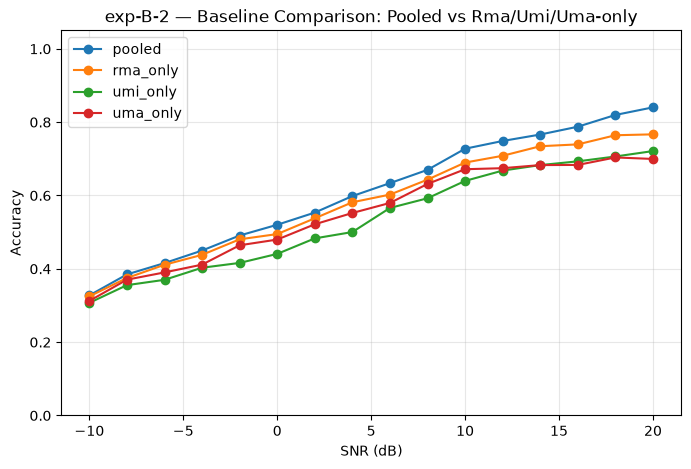

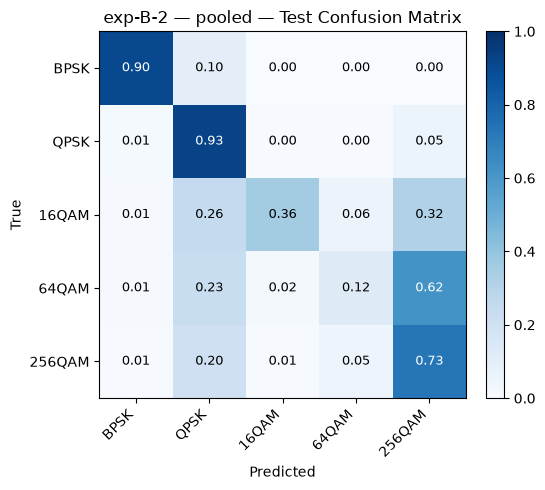

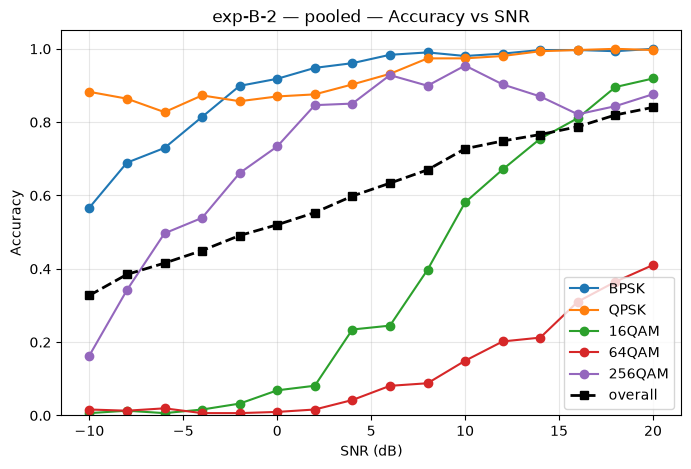

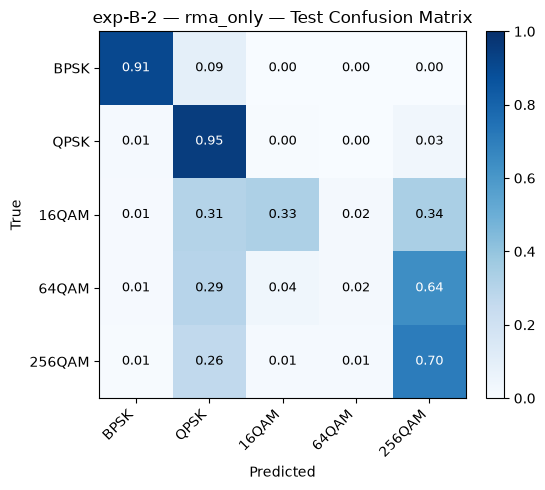

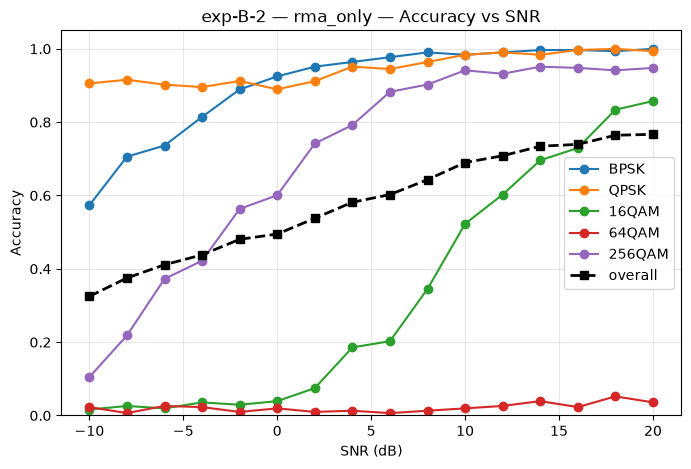

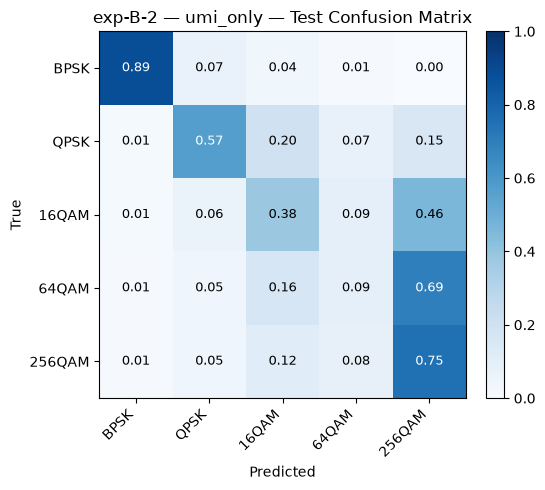

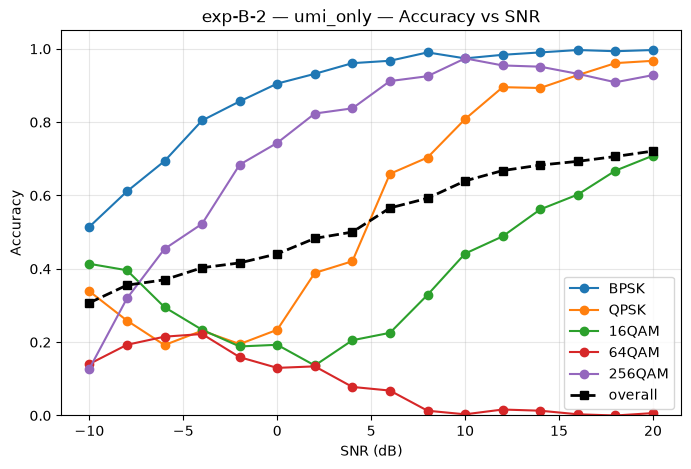

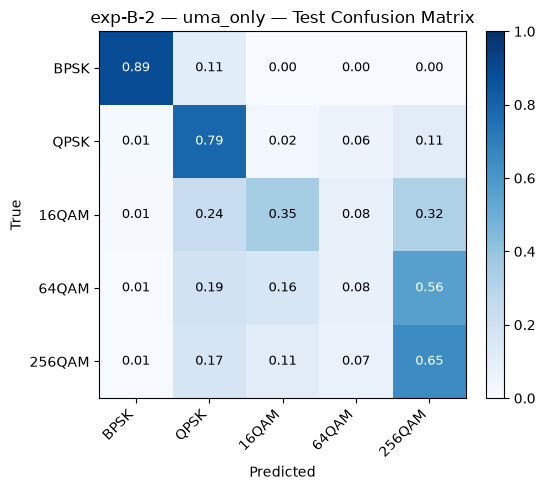

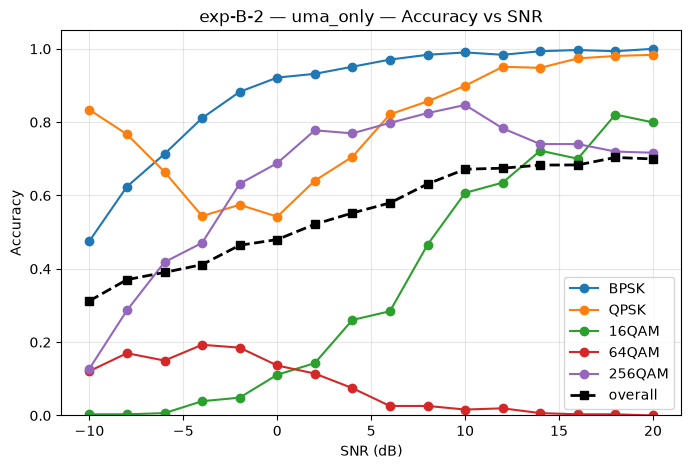

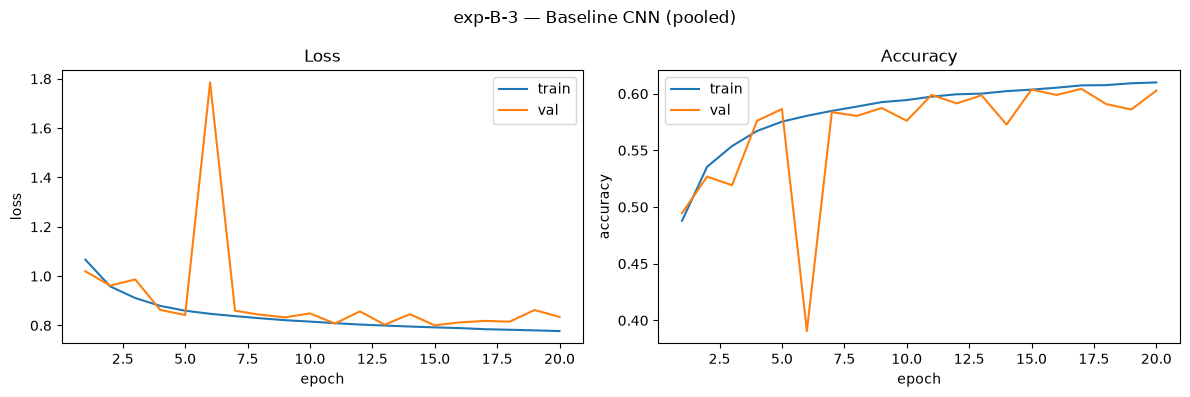

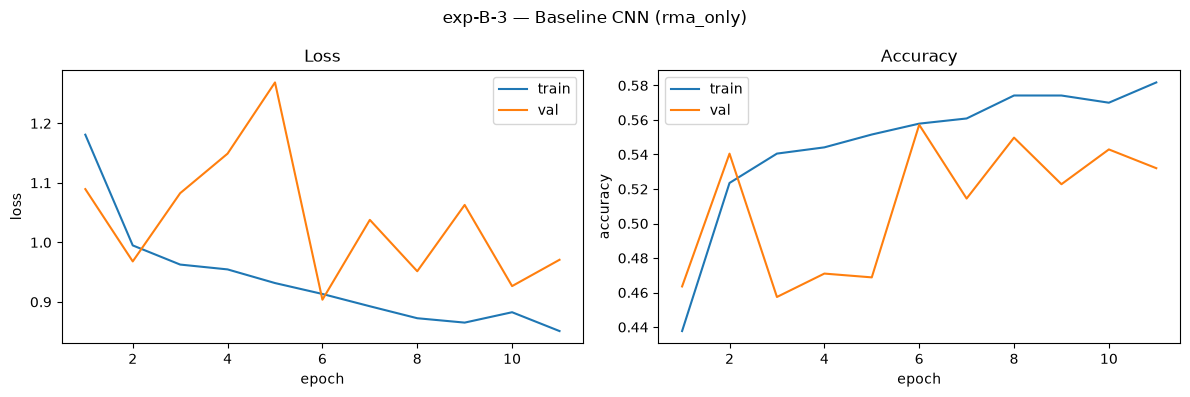

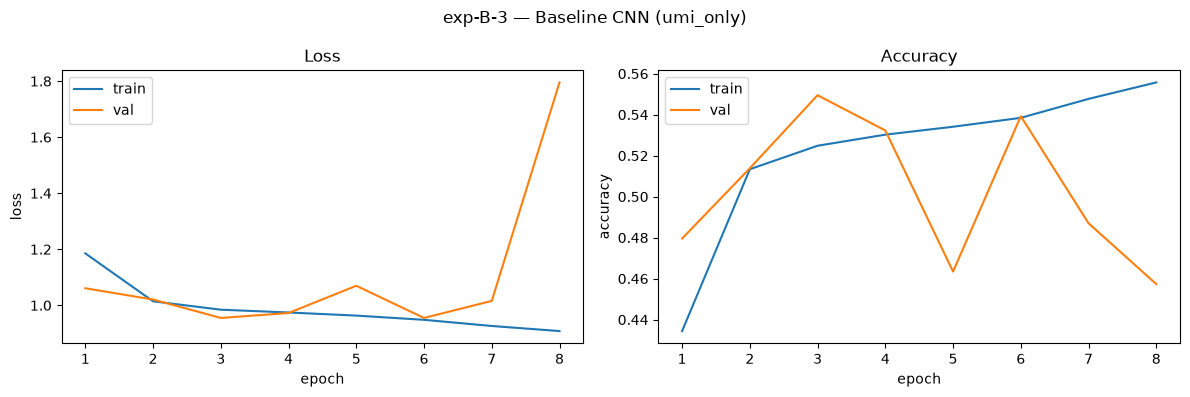

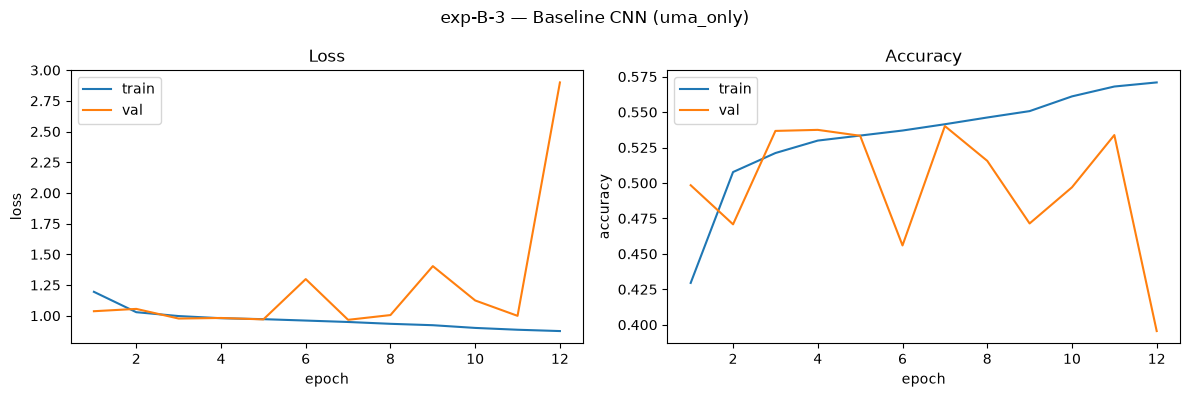

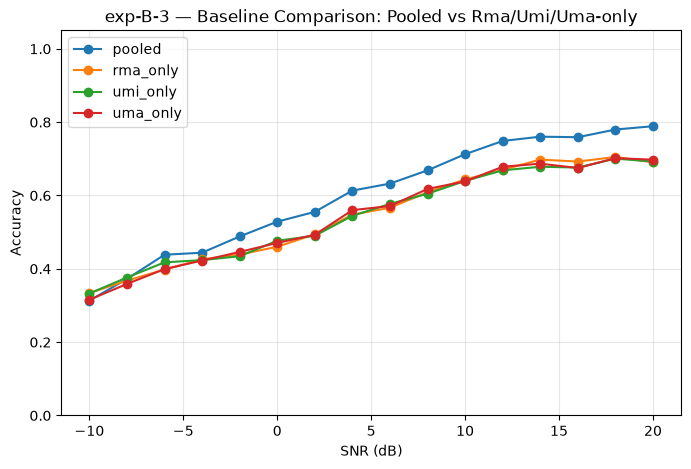

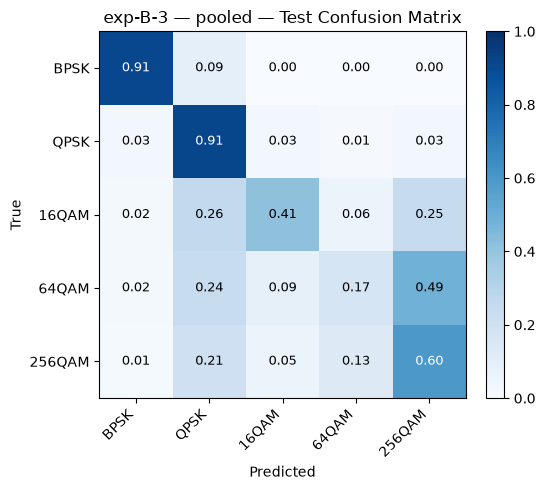

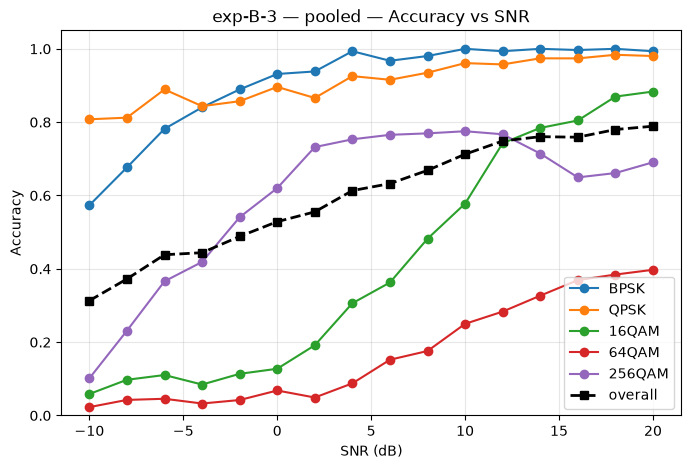

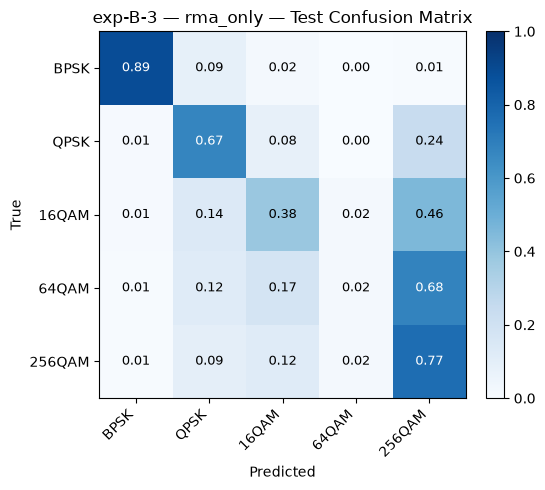

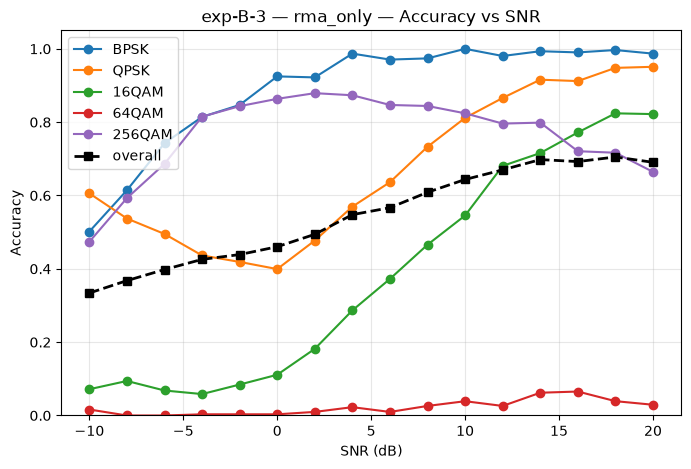

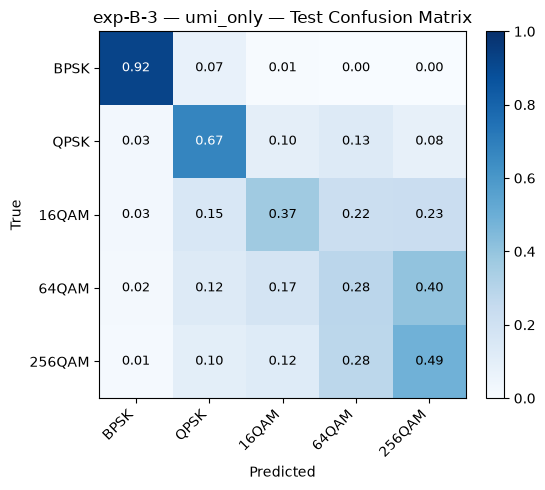

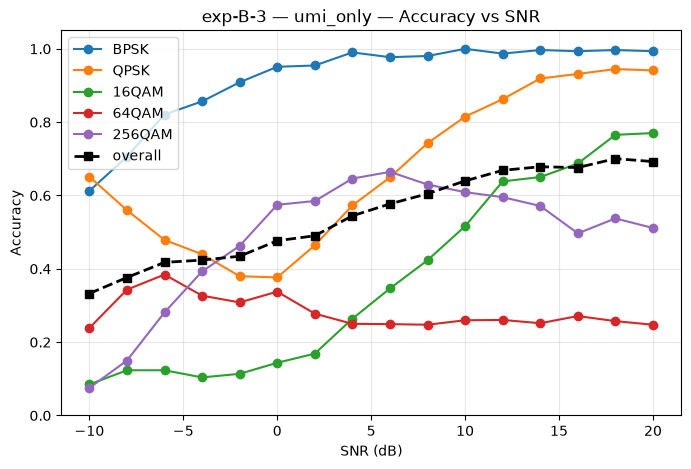

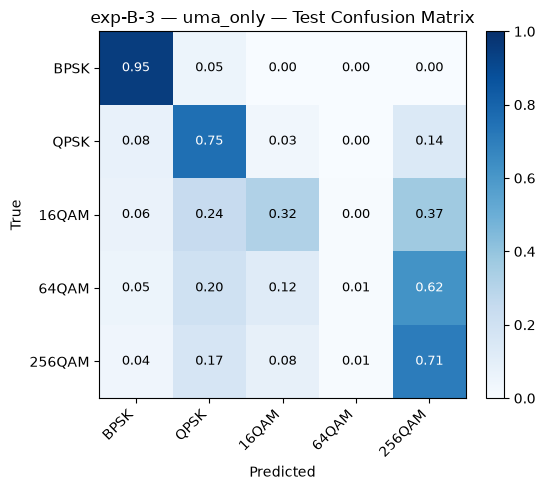

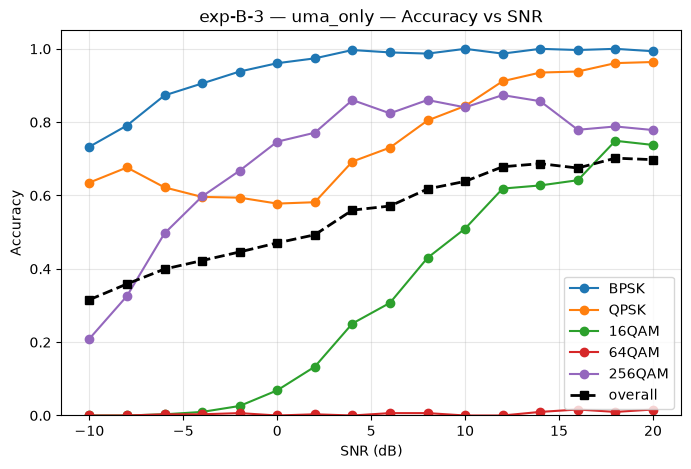

In [5]:
all_results = {}
all_histories = {}
 
for exp_key in exp_folders:
    print(f"\n########## {exp_key} ##########")
 
    train_path, val_path, test_path = split_paths_3dom(exp_key)
 
    histories = {}
    for variant_name, domain_filter in DOMAIN_VARIANTS:
        run_name = f"{exp_key}_baseline_{variant_name}"
        print(f"--- training {run_name} (domain_filter={domain_filter}) ---")
 
        history = train_model(
            model_cls     = BaselineCNN,
            run_name      = run_name,
            epochs        = 20,
            batch_size    = 256,
            lr            = 1e-3,
            normalize     = "per_sample",
            train_path    = train_path,
            val_path      = val_path,
            domain_filter = domain_filter,
        )
        histories[variant_name] = history
 
        plot_training_curves(history, title=f"{exp_key} — Baseline CNN ({variant_name})")
 
    all_histories[exp_key] = histories
 
    # -- Load best checkpoint for each variant --
    models = {}
    for variant_name, _ in DOMAIN_VARIANTS:
        run_name = f"{exp_key}_baseline_{variant_name}"
        models[variant_name] = load_best_model(run_name, device=device)
 
    # -- Evaluate all variants on this dataset's own fixed, pooled test set --
    test_ds = AMRDataset(test_path, normalize="per_sample")
    test_loader = DataLoader(test_ds, batch_size=256, shuffle=False)
    print(f"{exp_key} test set size: {len(test_ds)}")
 
    results = {}
    for variant_name, _ in DOMAIN_VARIANTS:
        results[variant_name] = collect_predictions(models[variant_name], test_loader, device)[:3]
 
    for variant_name, (mt, mp, _) in results.items():
        print(f"{exp_key}/{variant_name}: overall test accuracy = {(mt == mp).mean():.4f}")
 
    all_results[exp_key] = results
 
    # -- Comparison plot across variants --
    plot_accuracy_vs_snr_comparison(
        results, title=f"{exp_key} — Baseline Comparison: Pooled vs Rma/Umi/Uma-only"
    )
 
    # -- Confusion matrices + accuracy vs SNR, per variant --
    for variant_name, (mt, mp, snr_arr) in results.items():
        plot_confusion_matrix(mt, mp, title=f"{exp_key} — {variant_name} — Test Confusion Matrix")
        plot_accuracy_vs_snr(mt, mp, snr_arr, title=f"{exp_key} — {variant_name} — Accuracy vs SNR")
 
    # -- Accuracy vs SNR table, all variants side by side --
    tables = {v: accuracy_vs_snr_table(*results[v]) for v, _ in DOMAIN_VARIANTS}
    snr_levels = sorted(tables["pooled"]["overall"].keys())
 
    header = f"{'SNR':>6} | " + " | ".join(f"{v:>9}" for v, _ in DOMAIN_VARIANTS)
    print(header)
    for s in snr_levels:
        row = f"{s:6.1f} | " + " | ".join(f"{tables[v]['overall'][s]:9.3f}" for v, _ in DOMAIN_VARIANTS)
        print(row)
 
    print(f"=== {exp_key} — POOLED high-SNR confusion ===")
    high_snr_confusion(*results["pooled"])
 
    # -- Persist a lightweight accuracy summary for this dataset (avoids re-running to compare later) --
    summary_path = DATA_DIR / exp_key / "results.json"
    summary = {
        variant_name: float((mt == mp).mean())
        for variant_name, (mt, mp, _) in results.items()
    }
    with open(summary_path, "w") as f:
        json.dump(summary, f, indent=2)
    print(f"  saved accuracy summary -> {summary_path}")
 
    # -- Free memory before next dataset --
    del test_ds, test_loader, models
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
 
    print(f"########## Done with {exp_key} ##########")

## 6. Cross-dataset summary (overall test accuracy, all exp-k-i side by side)

In [6]:
variant_names = [v for v, _ in DOMAIN_VARIANTS]
 
header = f"{'exp-k-i':>10} | " + " | ".join(f"{v:>9}" for v in variant_names)
print(header)
for exp_key in exp_folders:
    row_vals = [f"{(mt == mp).mean():9.3f}" for v in variant_names for (mt, mp, _) in [all_results[exp_key][v]]]
    print(f"{exp_key:>10} | " + " | ".join(row_vals))

   exp-k-i |    pooled |  rma_only |  umi_only |  uma_only
   exp-A-1 |     0.558 |     0.475 |     0.533 |     0.539
   exp-A-2 |     0.652 |     0.613 |     0.600 |     0.614
   exp-A-3 |     0.608 |     0.582 |     0.576 |     0.557
   exp-B-1 |     0.555 |     0.486 |     0.517 |     0.518
   exp-B-2 |     0.608 |     0.581 |     0.534 |     0.552
   exp-B-3 |     0.600 |     0.546 |     0.546 |     0.546


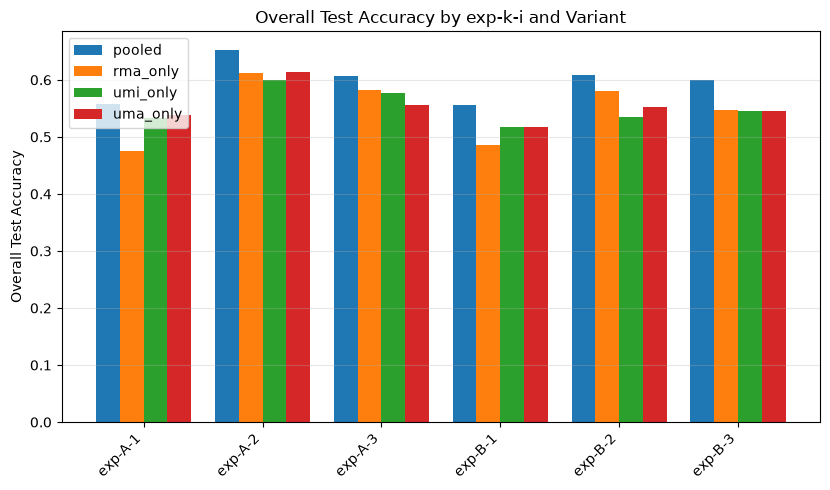

In [10]:
exp_keys_plotted = list(all_results.keys())
variant_names = [v for v, _ in DOMAIN_VARIANTS]

acc_matrix = np.array([
    [(mt == mp).mean() for v in variant_names for (mt, mp, _) in [all_results[exp_key][v]]]
    for exp_key in exp_keys_plotted
])

x = np.arange(len(exp_keys_plotted))
width = 0.8 / len(variant_names)

fig, ax = plt.subplots(figsize=(max(8, len(exp_keys_plotted) * 1.4), 5))

for i, variant_name in enumerate(variant_names):
    ax.bar(x + i * width, acc_matrix[:, i], width, label=variant_name)

ax.set_xticks(x + width * (len(variant_names) - 1) / 2)
ax.set_xticklabels(exp_keys_plotted, rotation=45, ha='right')
ax.set_ylabel("Overall Test Accuracy")
ax.set_title("Overall Test Accuracy by exp-k-i and Variant")
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 7. On-demand debugging: raw constellation samples for a given exp-k-i

In [7]:
MOD_NAMES = ['BPSK', 'QPSK', '16QAM', '64QAM', '256QAM']
 
 
def debug_constellations(exp_key, high_snr_threshold=15, train_loader=None):
    """
    Plots up to 3 high-SNR samples per modulation class, straight from the raw
    train.h5 file for `exp_key`. If `train_loader` is given, also plots the same
    check on a batch as seen by the model (post-normalization/collation).
    """
    train_path, _, _ = split_paths_3dom(exp_key)
 
    with h5py.File(train_path, "r") as f:
        data = f["Data"][:]
        mods = f["Mods"][:].argmax(axis=1)
        snrs = f["SNRs"][:]
 
    high_snr_mask = snrs >= high_snr_threshold
 
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    fig.suptitle(f"{exp_key} — raw high-SNR samples", y=1.05)
    for i, name in enumerate(MOD_NAMES):
        mask = high_snr_mask & (mods == i)
        idx = np.where(mask)[0][:3]
        for j in idx:
            row = data[j]
            axes[i].scatter(row.real, row.imag, s=3, alpha=0.5)
        axes[i].set_title(name)
        axes[i].set_xlabel("I")
        axes[i].set_ylabel("Q")
        axes[i].set_aspect("equal")
        axes[i].grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
 
    del data, mods, snrs
    gc.collect()
 
    if train_loader is not None:
        iq_batch, mod_batch, snr_batch, _ = next(iter(train_loader))
        high_snr = snr_batch >= high_snr_threshold
 
        fig, axes = plt.subplots(1, 5, figsize=(20, 4))
        fig.suptitle(f"{exp_key} — dataloader-batch high-SNR samples", y=1.05)
        for i, name in enumerate(MOD_NAMES):
            mask = high_snr & (mod_batch == i)
            idx = torch.where(mask)[0][:3]
            for j in idx:
                row = iq_batch[j]  # (2, 1024): I, Q
                axes[i].scatter(row[0], row[1], s=3, alpha=0.5)
            axes[i].set_title(name)
            axes[i].set_aspect("equal")
            axes[i].grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

In [9]:
# debug_constellations("exp-B-2")

## 8. Per-modulation accuracy table

In [13]:
import pandas as pd

MOD_NAMES = ['BPSK', 'QPSK', '16QAM', '64QAM', '256QAM']

def mod_accuracy(mt, mp, mod_idx):
    mask = mt == mod_idx
    if mask.sum() == 0:
        return np.nan
    return (mp[mask] == mod_idx).mean()

records = []
for exp_key in exp_keys_plotted:
    for variant_name in variant_names:
        mt, mp, _ = all_results[exp_key][variant_name]
        row = {'exp_key': exp_key, 'variant': variant_name}
        for i, name in enumerate(MOD_NAMES):
            row[name] = mod_accuracy(mt, mp, i)
        records.append(row)

mod_acc_df = pd.DataFrame(records)
mod_acc_df

,exp_key,variant,BPSK,QPSK,16QAM,64QAM,256QAM
0,exp-A-1,pooled,0.961914,0.659756,0.313606,0.059853,0.795200
1,exp-A-1,rma_only,0.939104,0.533130,0.312182,0.083673,0.504779
2,exp-A-1,umi_only,0.974745,0.717886,0.338011,0.054153,0.580639
3,exp-A-1,uma_only,0.963136,0.683130,0.354281,0.209487,0.484442
4,exp-A-2,pooled,0.982077,0.837398,0.480171,0.196050,0.766321
5,exp-A-2,rma_only,0.988595,0.768699,0.413870,0.183021,0.709986
6,exp-A-2,umi_only,0.976578,0.864431,0.454545,0.046010,0.657921
7,exp-A-2,uma_only,0.976986,0.812602,0.352654,0.100366,0.825097
8,exp-A-3,pooled,0.966191,0.779878,0.489730,0.086116,0.715884
9,exp-A-3,rma_only,0.954990,0.878049,0.278422,0.079805,0.717714


## 6.3 Best exp-k-i / variant per modulation

modulation best_exp_key best_variant  accuracy
      BPSK      exp-A-2     rma_only  0.988595
      QPSK      exp-B-2     rma_only  0.946341
     16QAM      exp-A-3       pooled  0.489730
     64QAM      exp-B-1     rma_only  0.510586
    256QAM      exp-A-3     uma_only  0.849502


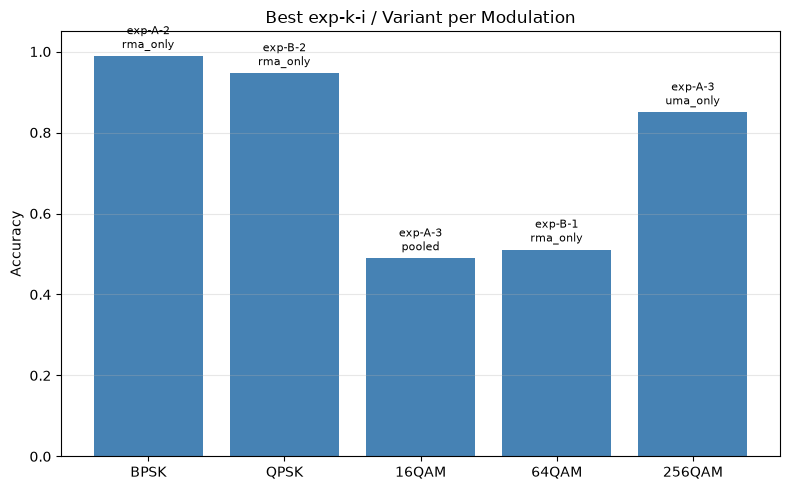

In [14]:
best_per_mod = []
for name in MOD_NAMES:
    idx = mod_acc_df[name].idxmax()
    best_per_mod.append({
        'modulation': name,
        'best_exp_key': mod_acc_df.loc[idx, 'exp_key'],
        'best_variant': mod_acc_df.loc[idx, 'variant'],
        'accuracy': mod_acc_df.loc[idx, name],
    })

best_df = pd.DataFrame(best_per_mod)
print(best_df.to_string(index=False))

# -- Plot --
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(best_df['modulation'], best_df['accuracy'], color='steelblue')

for bar, (_, row) in zip(bars, best_df.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
        f"{row['best_exp_key']}\n{row['best_variant']}",
        ha='center', va='bottom', fontsize=8
    )

ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1.05)
ax.set_title("Best exp-k-i / Variant per Modulation")
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()